In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings
import numpy as np

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    load_population_results, aggregate_population,
    run_population_tests, run_fraction_sig_tests, run_r2_tests,
    plot_population_results, plot_r2_distributions, plot_beta_distributions,
    build_population_scatter, save_population_results,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

# Population ridge regression — spe-1

Pool single-cell ridge regression results across all recorded cells and test whether
waveform features systematically predict LFP state at the population level.

**Analysis steps**
1. Load per-cell result pickles
2. Aggregate R², significance flags, and beta weights across cells
3. Population tests:
   - Beta consistency (one-sample Wilcoxon signed-rank, median ≠ 0)
   - Fraction significant cells > chance (binomial test)
   - **Primary**: median CV R² > 0 across cells (one-sided Wilcoxon)
4. Visualise: R² heatmap, beta heatmap, per-cell R² and beta distributions
5. Actual vs predicted scatter (pooled across significant cells)
6. Save population pickle

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
PRE_WIN          = (-0.055, -0.005)
POST_WIN         = ( 0.005,  0.055)
BASELINE_WIN     = (-0.20,  -0.10)
FDR_Q            = 0.05
MIN_CELLS        = 5

## Configuration

`PRE_WIN` / `POST_WIN`: time windows (s) around the spike used to extract LFP features.  
`BASELINE_WIN`: window used for baseline correction of windowed LFP features.  
`FDR_Q`: Benjamini–Hochberg FDR threshold.  
`MIN_CELLS`: minimum cells required to run a population test for a given target.

**LFP amplitude/std targets — HPF detrending**  
Pre- and post-spike LFP amplitude and std are computed from raw per-spike LFP windows  
high-pass filtered at **0.1 Hz** (4th-order zero-phase Butterworth, `sosfiltfilt`) before  
extracting the windowed mean and std. This removes slow electrode drift (timescales > 10 s)  
while preserving network-state fluctuations at biologically relevant timescales.  
All other targets (gamma AUC, exponent, theta AUC) are unaffected by the HPF.  
A comparison of results with and without HPF is shown in §7.

In [3]:
# ── Load all cell pickles ──────────────────────────────────────────────────────
all_results, cell_ids, target_names, predictor_sets = load_population_results(RIDGE_PICKLE_DIR)

feat_labels   = FEAT_LABELS
target_labels = (
    [f'Pre {l}'     for l in feat_labels] +
    [f'Pre−BL {l}'  for l in feat_labels] +
    [f'Post {l}'    for l in feat_labels] +
    [f'Post−BL {l}' for l in feat_labels] +
    [f'Δ {l}'       for l in feat_labels]
)

print(f'Loaded {len(all_results)} cells  |  {len(target_names)} targets')

Loaded 37 cells  |  25 targets  |  3 predictor sets
Loaded 37 cells  |  25 targets


## 1. Load per-cell results

In [4]:
# ── 2. Aggregate R², significance, and betas across cells ──────────────────────
r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

## 2. Aggregate across cells

`r2_pop`   — CV R² per cell per (target × predictor set)  
`sig_pop`  — cell-level FDR significance flags  
`beta_pop` — waveform beta weights (Waveform only model) per cell

In [5]:
# ── 3a. R² > 0 test first — identifies which targets are worth testing betas on
df_frac = run_fraction_sig_tests(
    sig_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, fdr_q=FDR_Q,
)
df_r2 = run_r2_tests(
    r2_pop, target_names, target_labels, predictor_sets,
    min_cells=MIN_CELLS, fdr_q=FDR_Q,
)

# Targets with significant R² under Waveform-only (primary predictor set)
sig_r2_targets = (
    df_r2[df_r2['sig_r2'] & (df_r2['predictor_set'] == 'Waveform only')]
    ['target'].tolist()
)
print(f'\nR²-significant targets (Waveform only): {sig_r2_targets}')

# ── 3b. Beta consistency — only on R²-significant targets ─────────────────────
# FDR corrects over n_sig_targets × 8 features (not all 200 pairs),
# which is the correct hierarchical approach.
df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, fdr_q=FDR_Q,
    sig_r2_targets=sig_r2_targets,
)

Fraction-sig binomial tests: 75 (target × predictor_set) pairs  |  raw p<0.05: 64  |  FDR q<0.05: 64
     target_label      predictor_set  n_sig  n_cells  frac_sig  p_binom_fdr
      Pre LFP Amp      Waveform only     22       37  0.594595 1.606452e-18
      Pre LFP Amp       Log ISI only     14       37  0.378378 3.012758e-09
      Pre LFP Amp Waveform + Log ISI     24       37  0.648649 8.404510e-21
      Pre LFP Std      Waveform only     16       37  0.432432 2.438466e-11
      Pre LFP Std       Log ISI only     12       37  0.324324 2.825615e-07
      Pre LFP Std Waveform + Log ISI     20       37  0.540541 5.519340e-16
    Pre Gamma AUC      Waveform only     13       37  0.351351 3.075671e-08
    Pre Gamma AUC Waveform + Log ISI     14       37  0.378378 3.012758e-09
     Pre Exponent      Waveform only     15       37  0.405405 3.112809e-10
     Pre Exponent       Log ISI only      9       37  0.243243 1.013124e-04
     Pre Exponent Waveform + Log ISI     16       37  0.432432 

In [6]:
# ── 3a-i. Focused beta table: all Pre-window LFP targets × waveform features ──
# Raw one-sample t-test p-values (uncorrected, standardised betas) for each
# waveform feature, shown separately for each of the 5 pre-spike LFP targets.
# Sorted by raw p-value within each target.
from IPython.display import display, HTML
import pandas as pd

PRE_TARGETS = [
    ('pre_lfp_amp',   'Pre LFP Amp'),
    ('pre_lfp_std',   'Pre LFP Std'),
    ('pre_gamma_auc', 'Pre Gamma AUC'),
    ('pre_exponent',  'Pre Exponent'),
    ('pre_theta_auc', 'Pre Theta AUC'),
]

for tn, tl in PRE_TARGETS:
    focused = (
        df_tests[df_tests['target'] == tn]
        [['feature', 'n', 'mean_beta', 'sem_beta', 't_stat', 'p_val']]
        .sort_values('p_val')
        .reset_index(drop=True)
    )
    focused.columns = ['Feature', 'N cells', 'Mean β', 'SEM β', 't', 'p (raw)']

    styled = (
        focused.style
        .format({'Mean β': '{:+.4f}', 'SEM β': '{:.4f}',
                 't': '{:+.3f}', 'p (raw)': '{:.4f}'})
        .background_gradient(subset=['p (raw)'], cmap='YlOrRd_r', vmin=0, vmax=0.5)
        .set_caption(f'{tl} — one-sample t-test on β across cells (n=37), uncorrected')
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '13px'), ('font-weight', 'bold'),
                                      ('text-align', 'left'), ('padding-bottom', '4px')]}])
    )
    display(styled)
    display(HTML('<br/>'))

,Feature,N cells,Mean β,SEM β,t,p (raw)
0,Infl. Amp,37,+0.0221,0.0097,+2.290,0.0280
1,Ramp Amp,37,-0.0082,0.0045,-1.812,0.0783
2,Infl. Time,37,+0.0054,0.0043,+1.277,0.2097
3,Sharpness,37,-0.0411,0.0323,-1.272,0.2116
4,Decay λ,37,-0.0098,0.0100,-0.978,0.3347
5,Decay Const,37,+0.0081,0.0089,+0.914,0.3669
6,Peak Amp,37,+0.0211,0.0311,+0.677,0.5027
7,Peak Width,37,-0.0027,0.0137,-0.199,0.8432


,Feature,N cells,Mean β,SEM β,t,p (raw)


,Feature,N cells,Mean β,SEM β,t,p (raw)


,Feature,N cells,Mean β,SEM β,t,p (raw)


,Feature,N cells,Mean β,SEM β,t,p (raw)


## 3. Population tests

**Order matters** — R² tests run first, beta tests restricted to R²-significant targets.

**3a — R² > 0** (`run_r2_tests`): one-sided Wilcoxon on CV R² across cells. The **primary test** — requires the model to have a non-trivial positive effect size, not just cell-level significance. FDR-corrected over all 75 (target × predictor_set) pairs.

**3a — Fraction significant** (`run_fraction_sig_tests`): binomial test — is the fraction of FDR-significant cells greater than chance (p=0.05)? Confirms significance is distributed across cells, not driven by outliers.

**3b — Beta consistency** (`run_population_tests`): one-sample t-test and Wilcoxon signed-rank on betas across cells (mean/median ≠ 0). **Restricted to R²-significant targets only** — FDR corrects over n_sig×8 pairs instead of 200, which is the correct hierarchical approach.

**3b — Fraction significant** (`run_fraction_sig_tests`): binomial test — is the fraction of FDR-significant cells greater than expected by chance (p=0.05)? Confirms that significance is distributed across many cells, not driven by a few outliers.

**3c — Median R² > 0** (`run_r2_tests`): one-sided Wilcoxon on CV R² across cells. This is the **primary meaningful test** — requires the effect size (R²) to be non-trivially positive, not just that more cells pass their permutation threshold than expected.

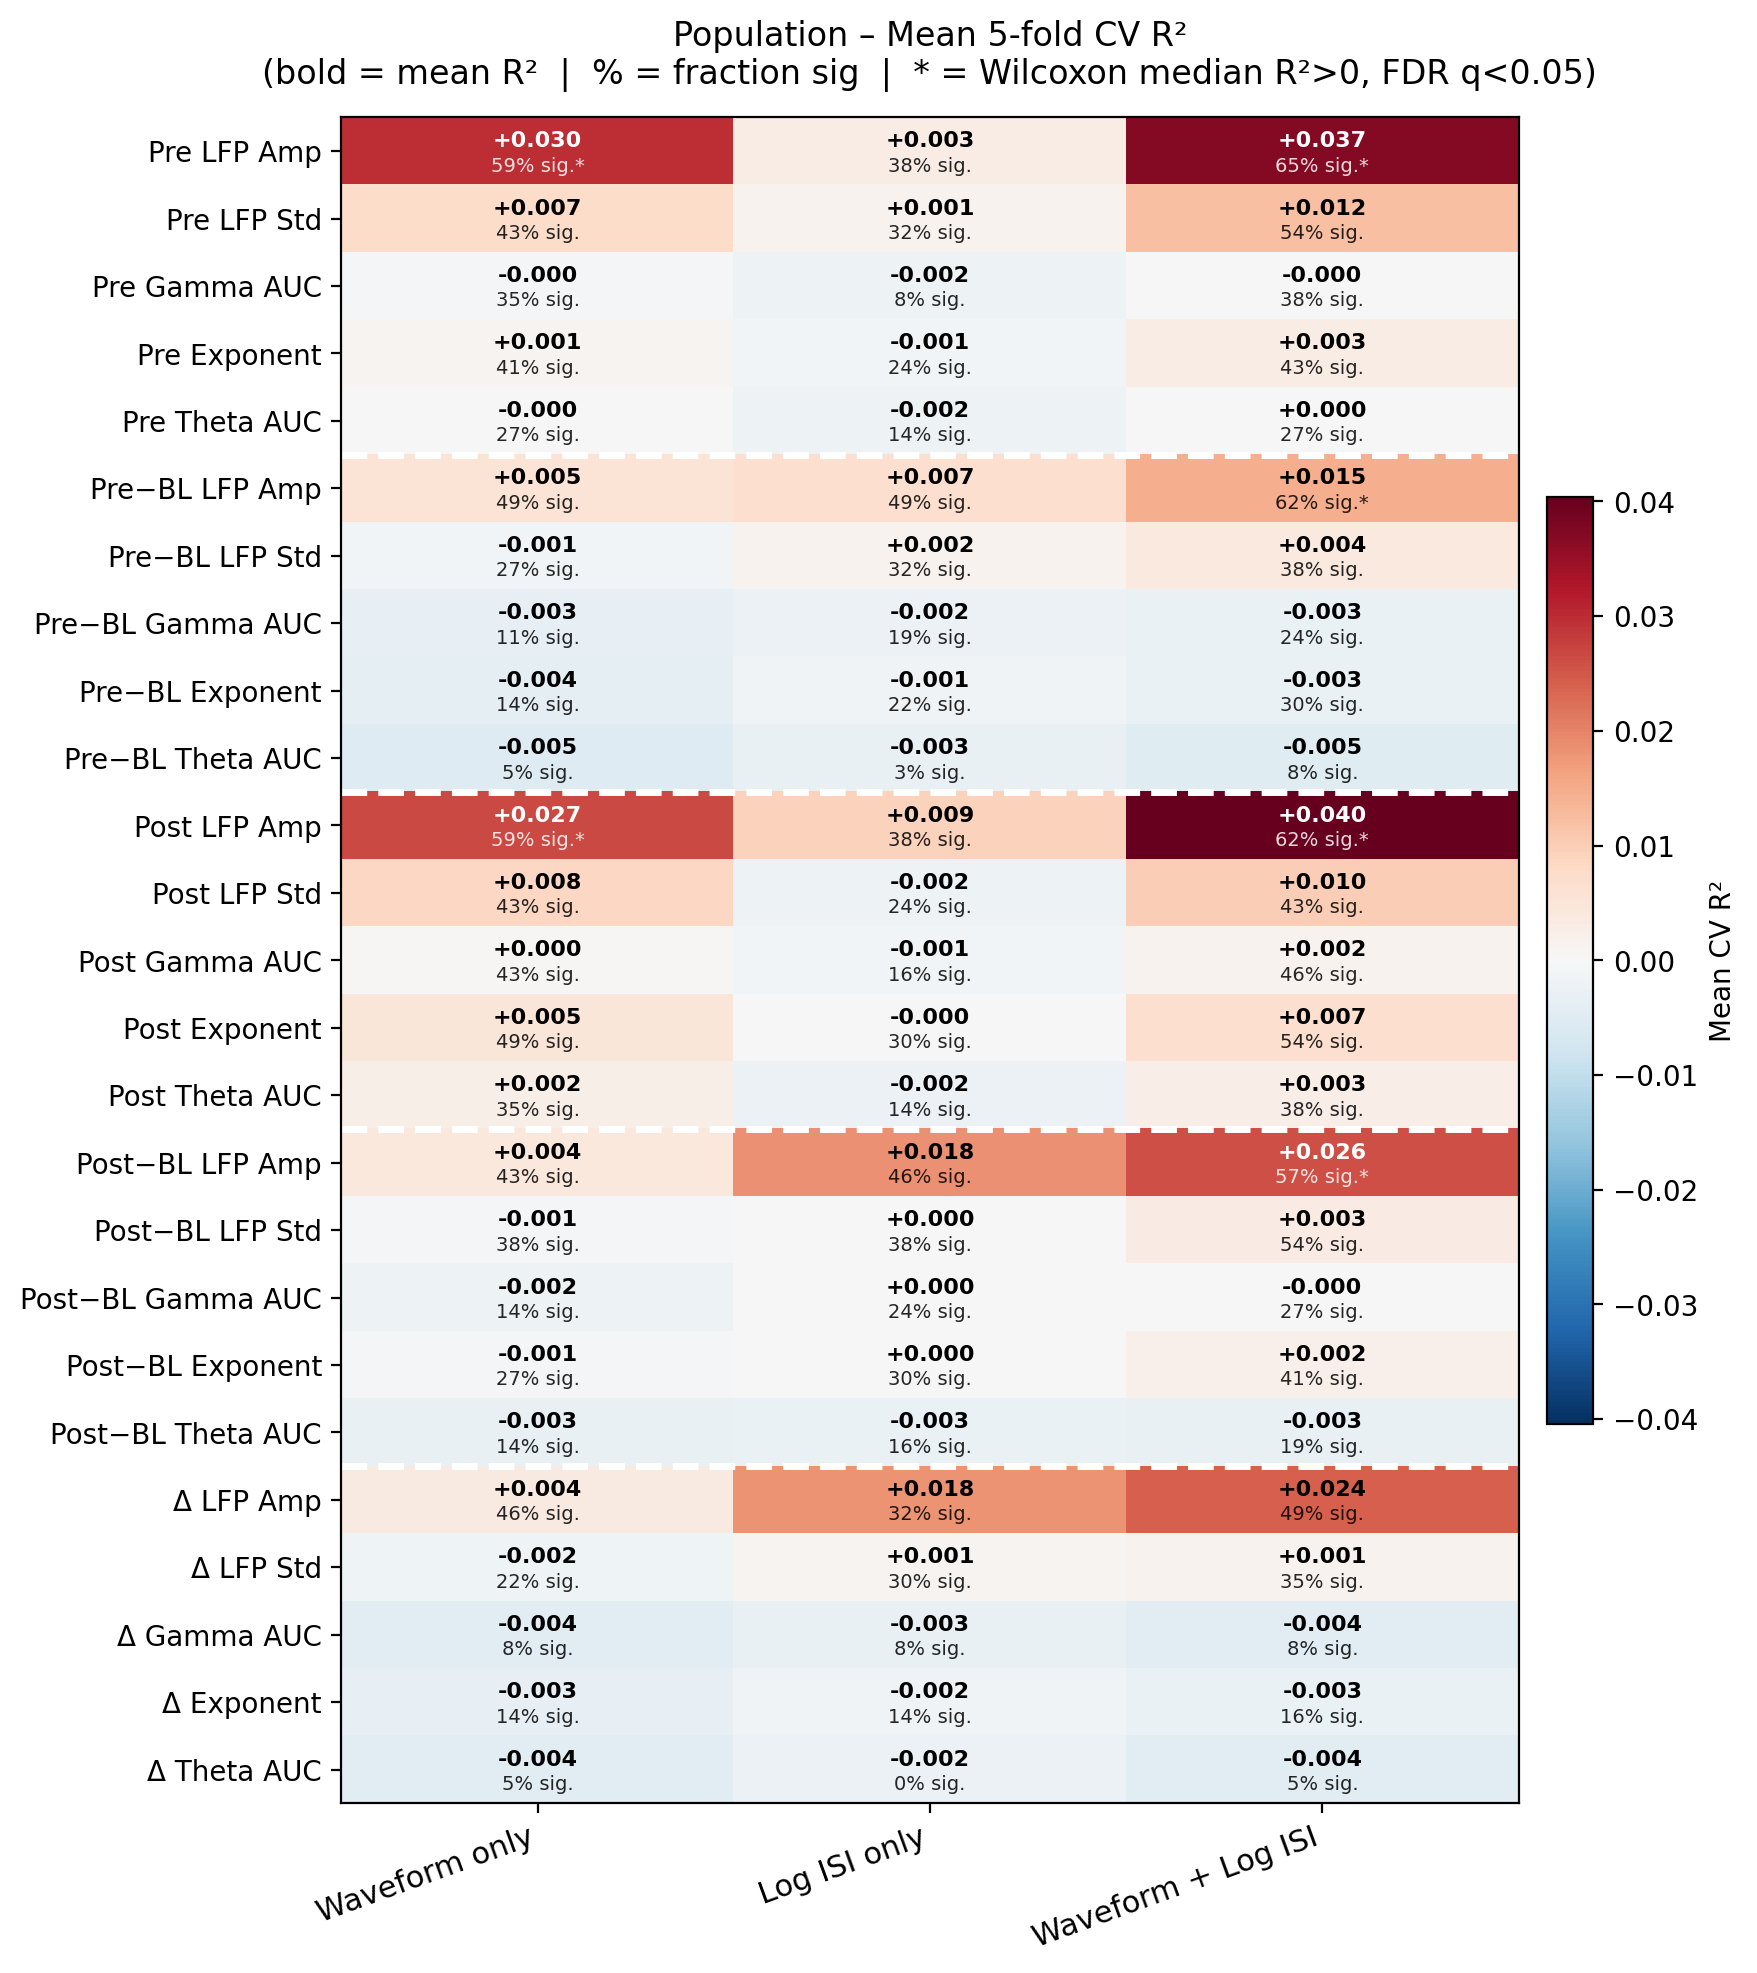

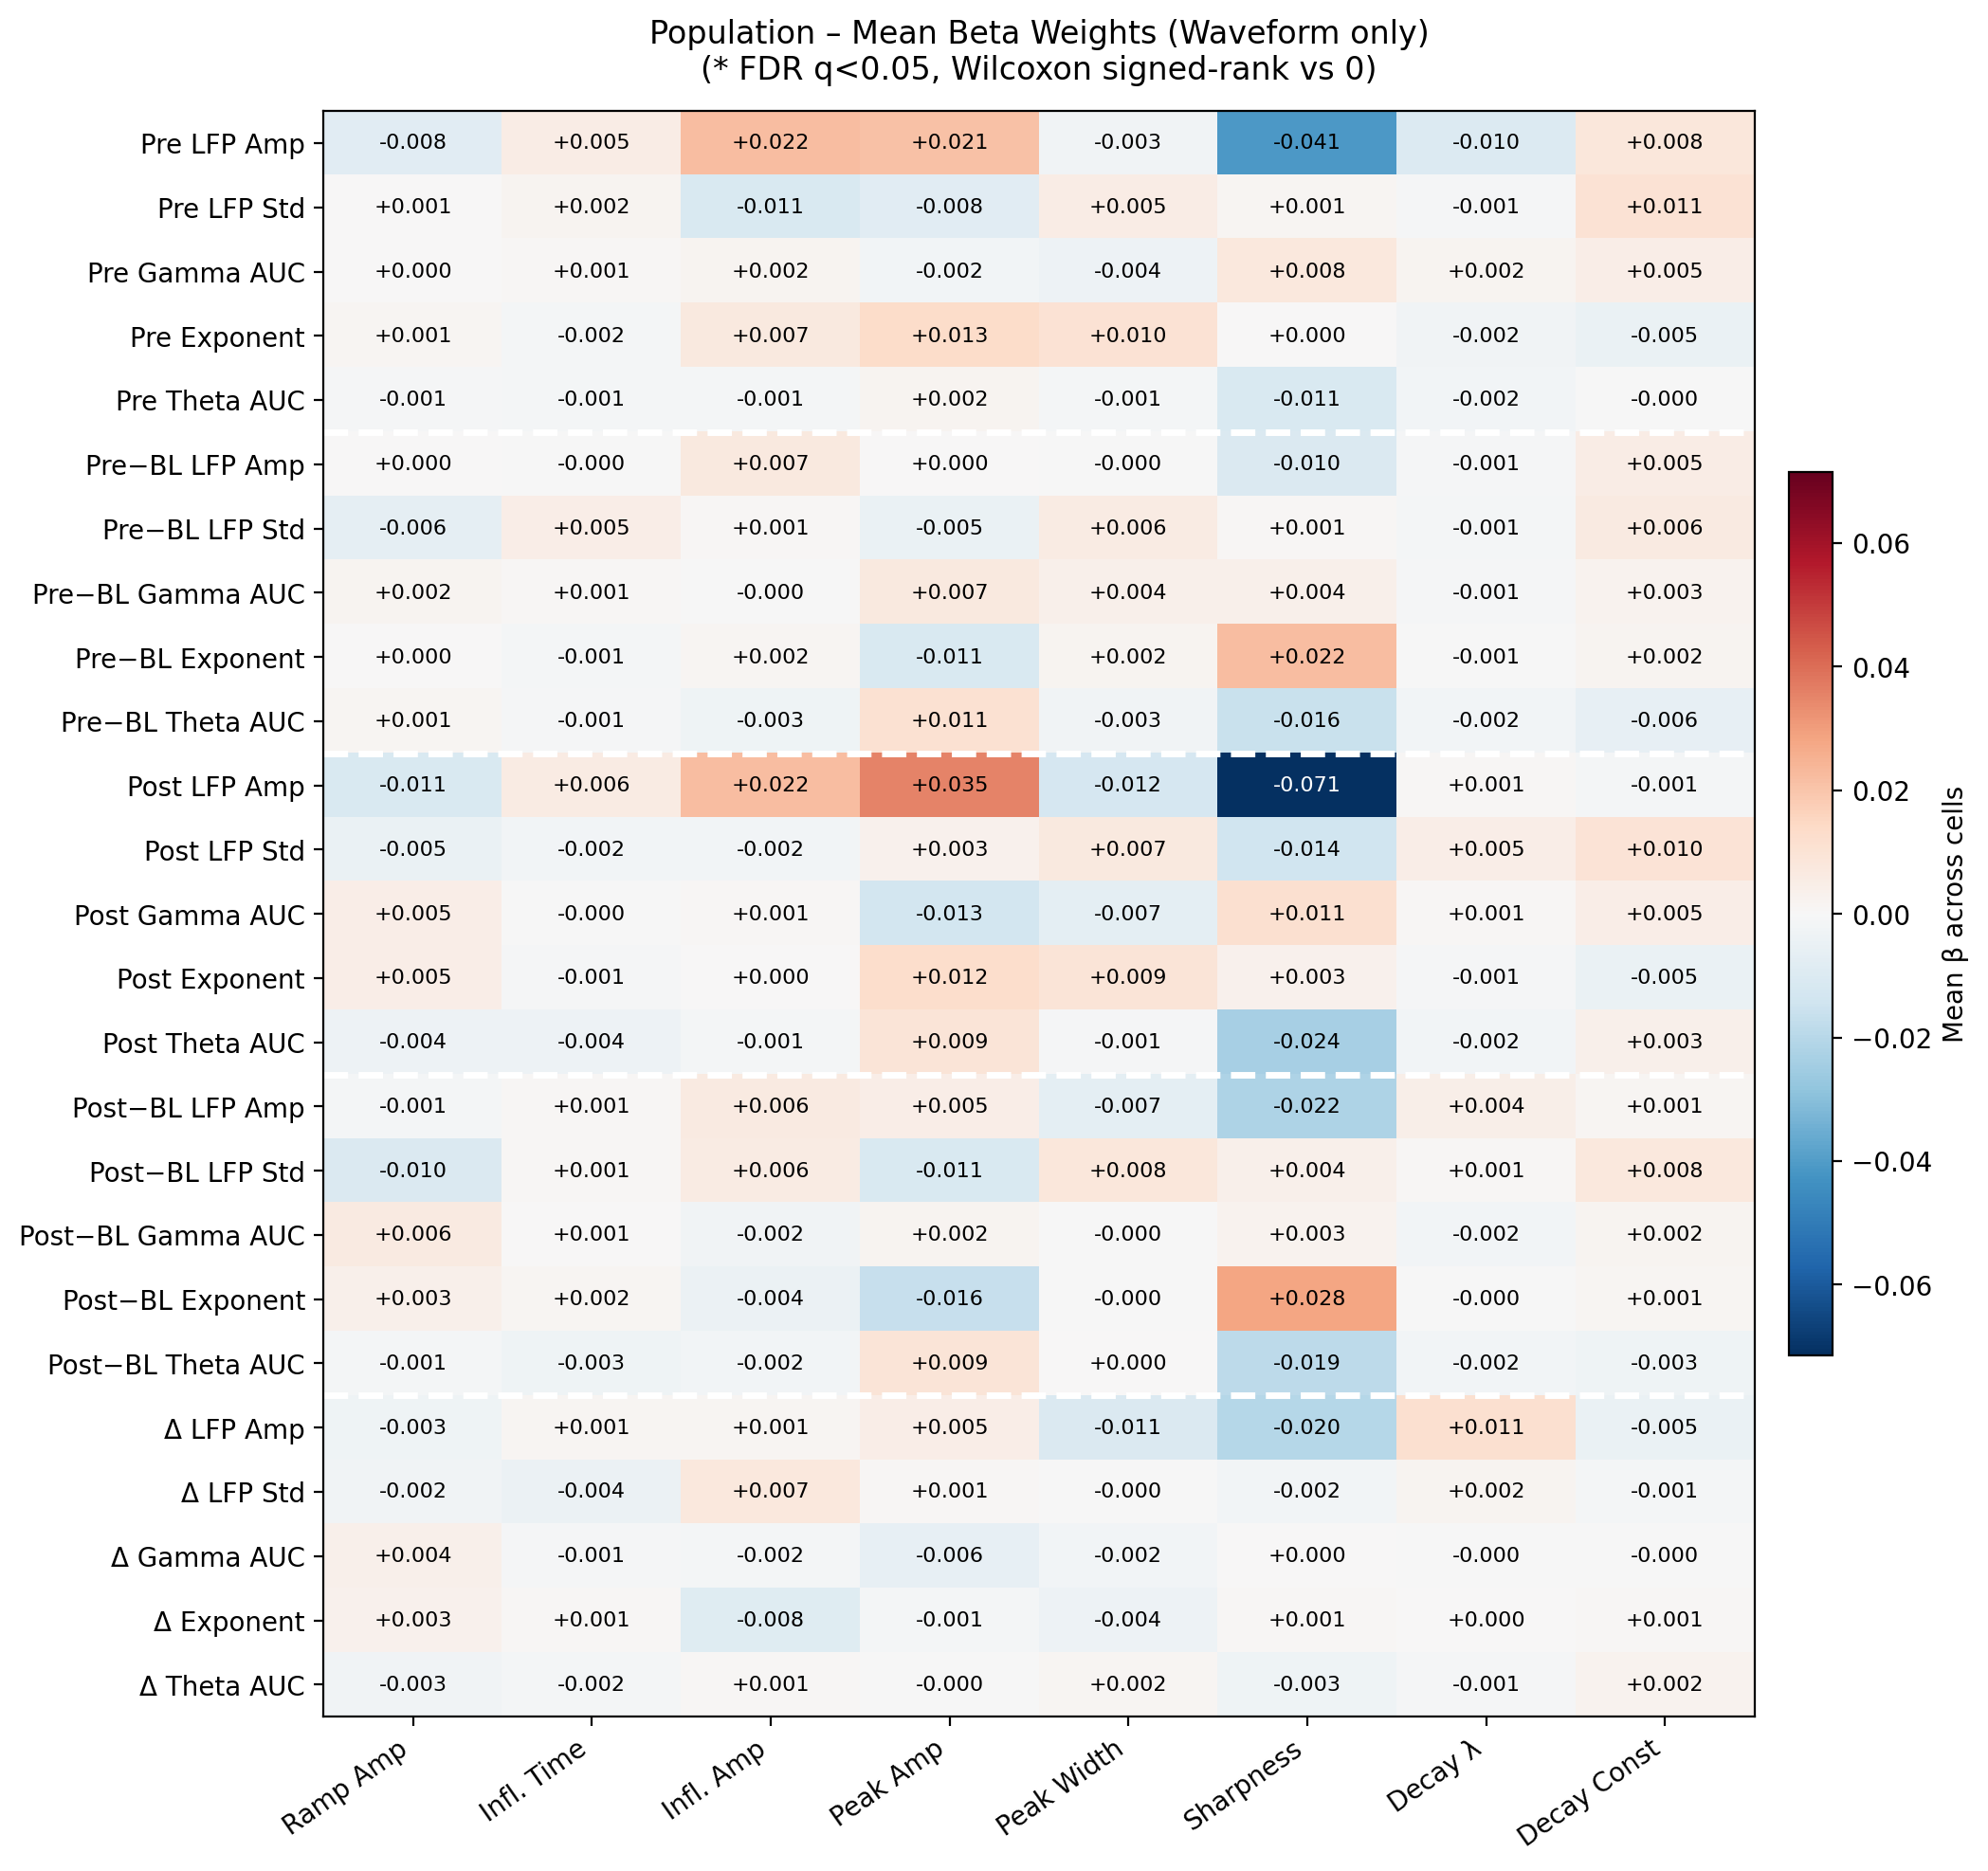

No population-level FDR-significant pairs.


In [7]:
# ── 4. Plots: R² heatmap, beta heatmap, rainclouds ────────────────────────────
mean_r2, frac_sig, mean_beta_mat, sig_beta_mat = plot_population_results(
    r2_pop, sig_pop, beta_pop, df_tests,
    target_names, target_labels, predictor_sets,
    df_frac=df_frac, df_r2=df_r2,
)

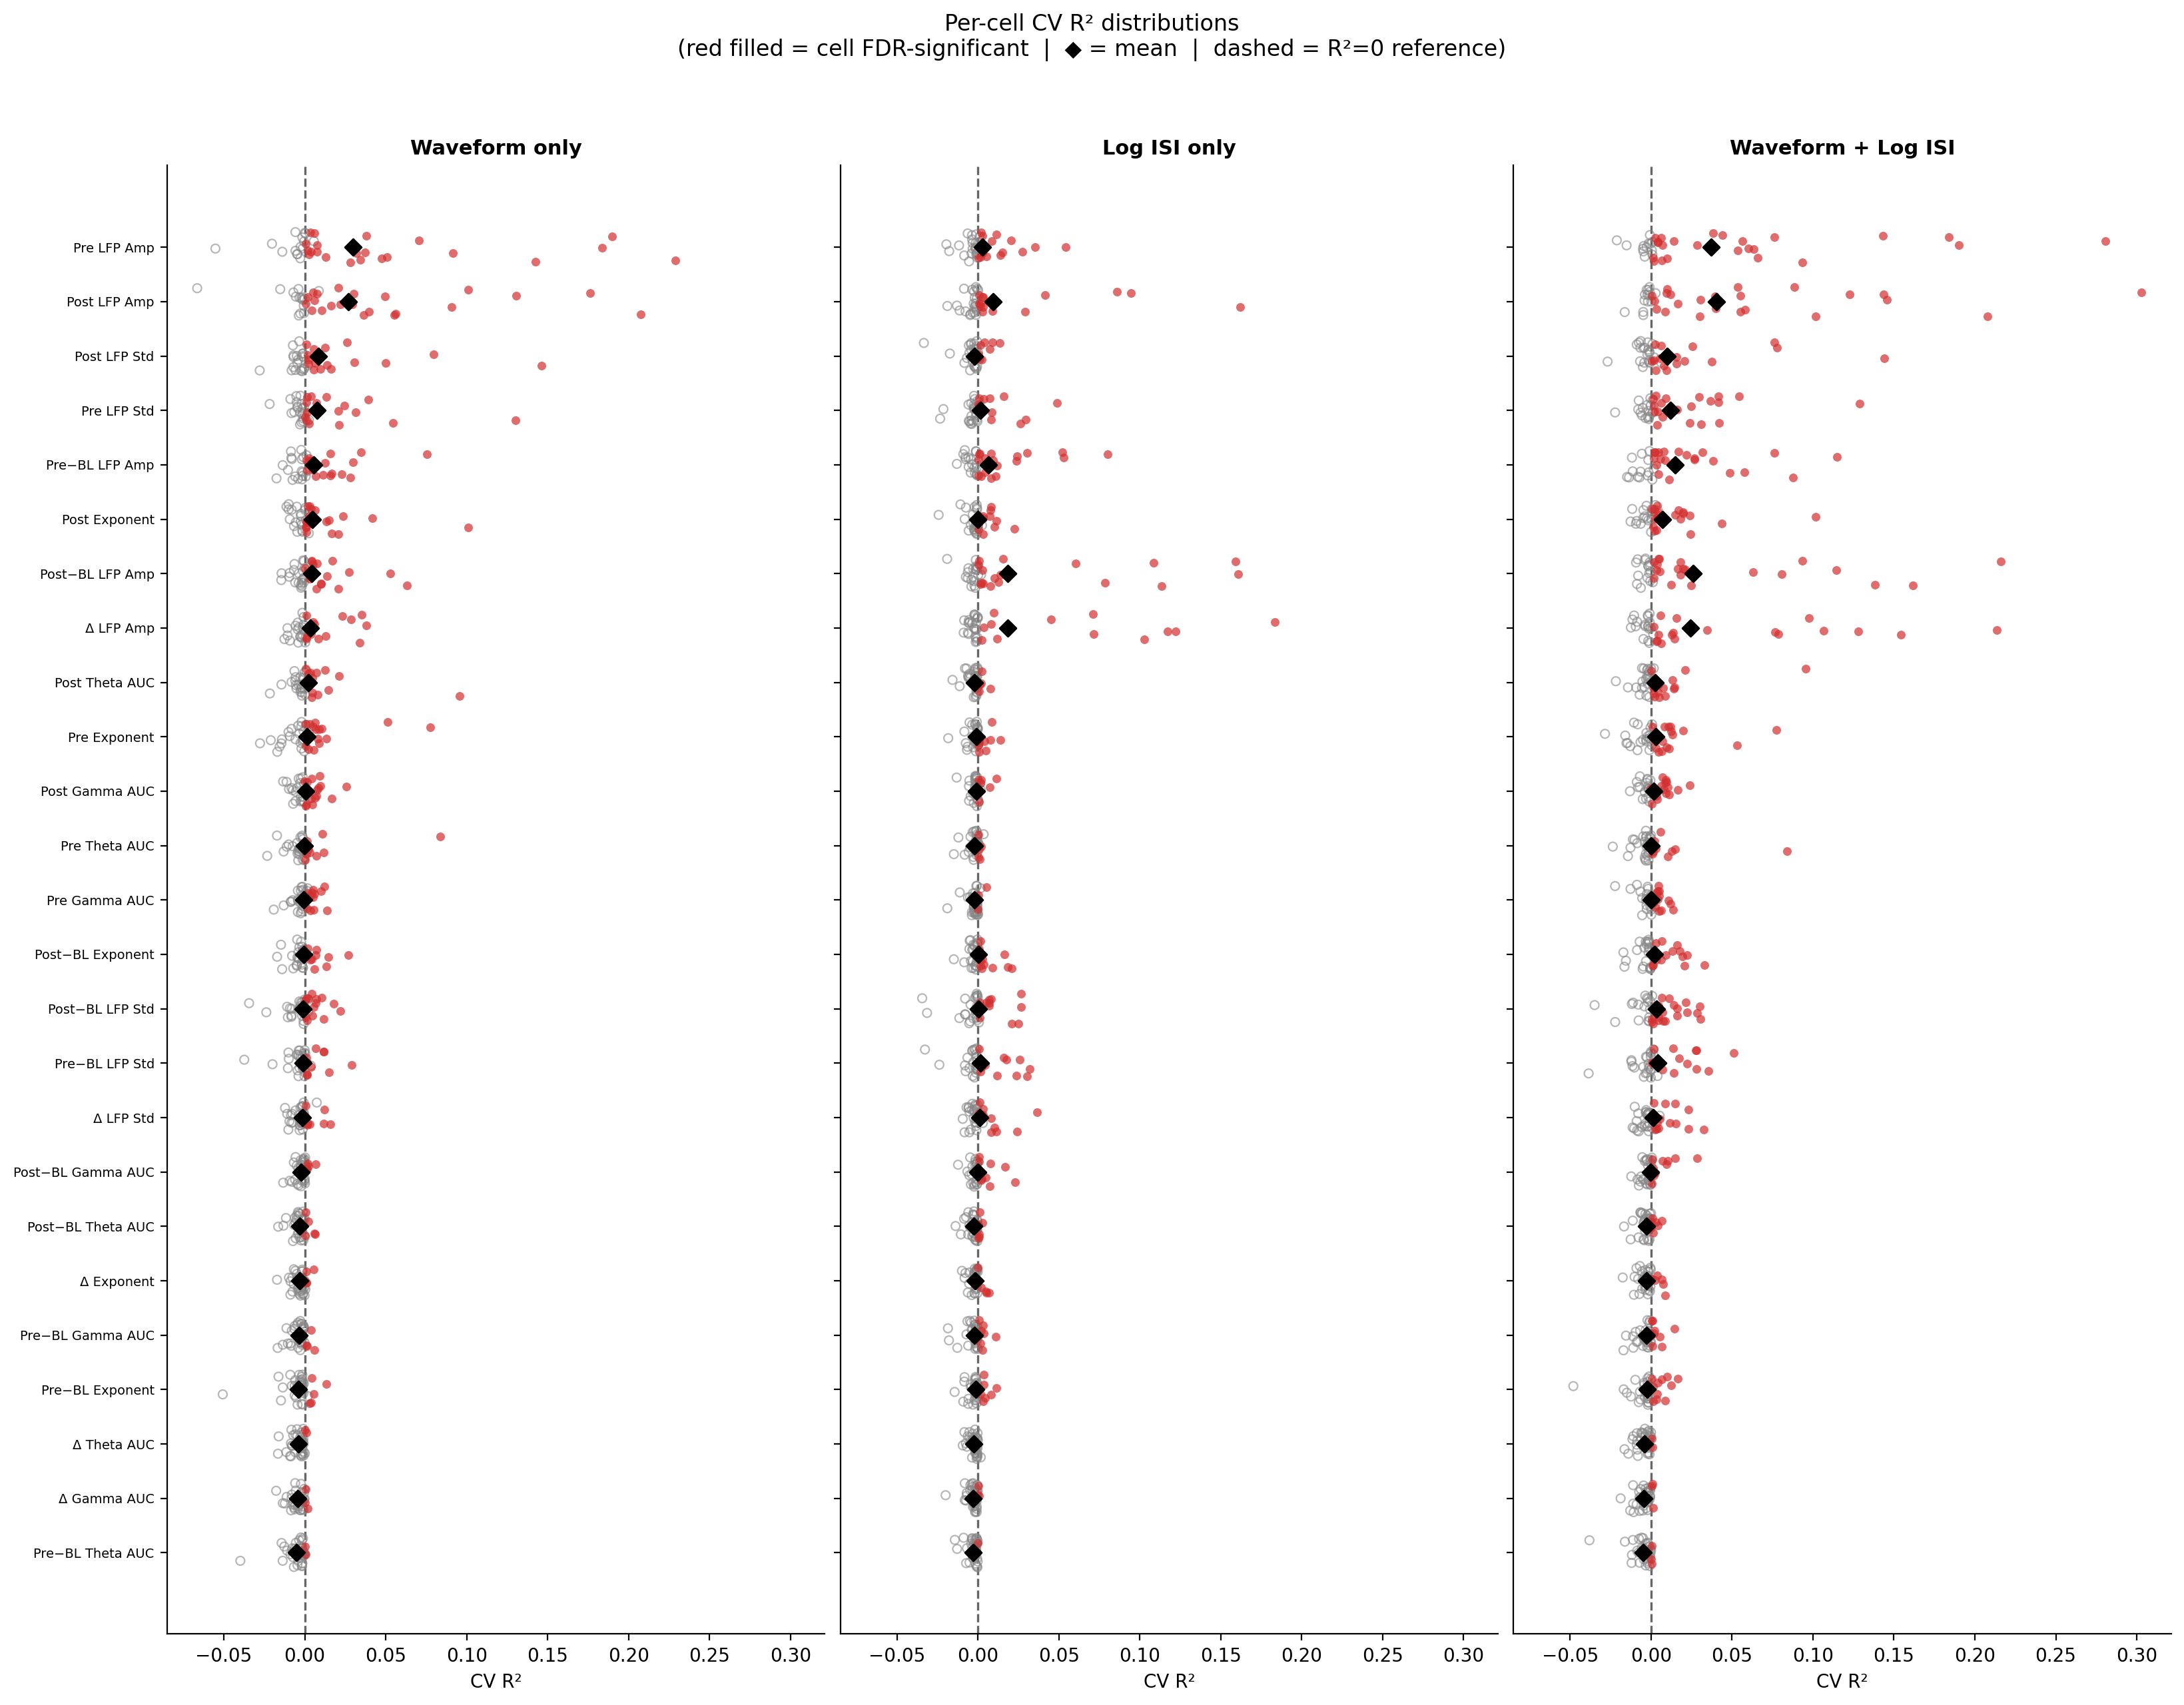

In [8]:
# ── 4b. R² distribution across cells ─────────────────────────────────────────
plot_r2_distributions(
    r2_pop, sig_pop, target_names, target_labels, predictor_sets,
    sort_by='Waveform only', min_r2_line=0.01,
)

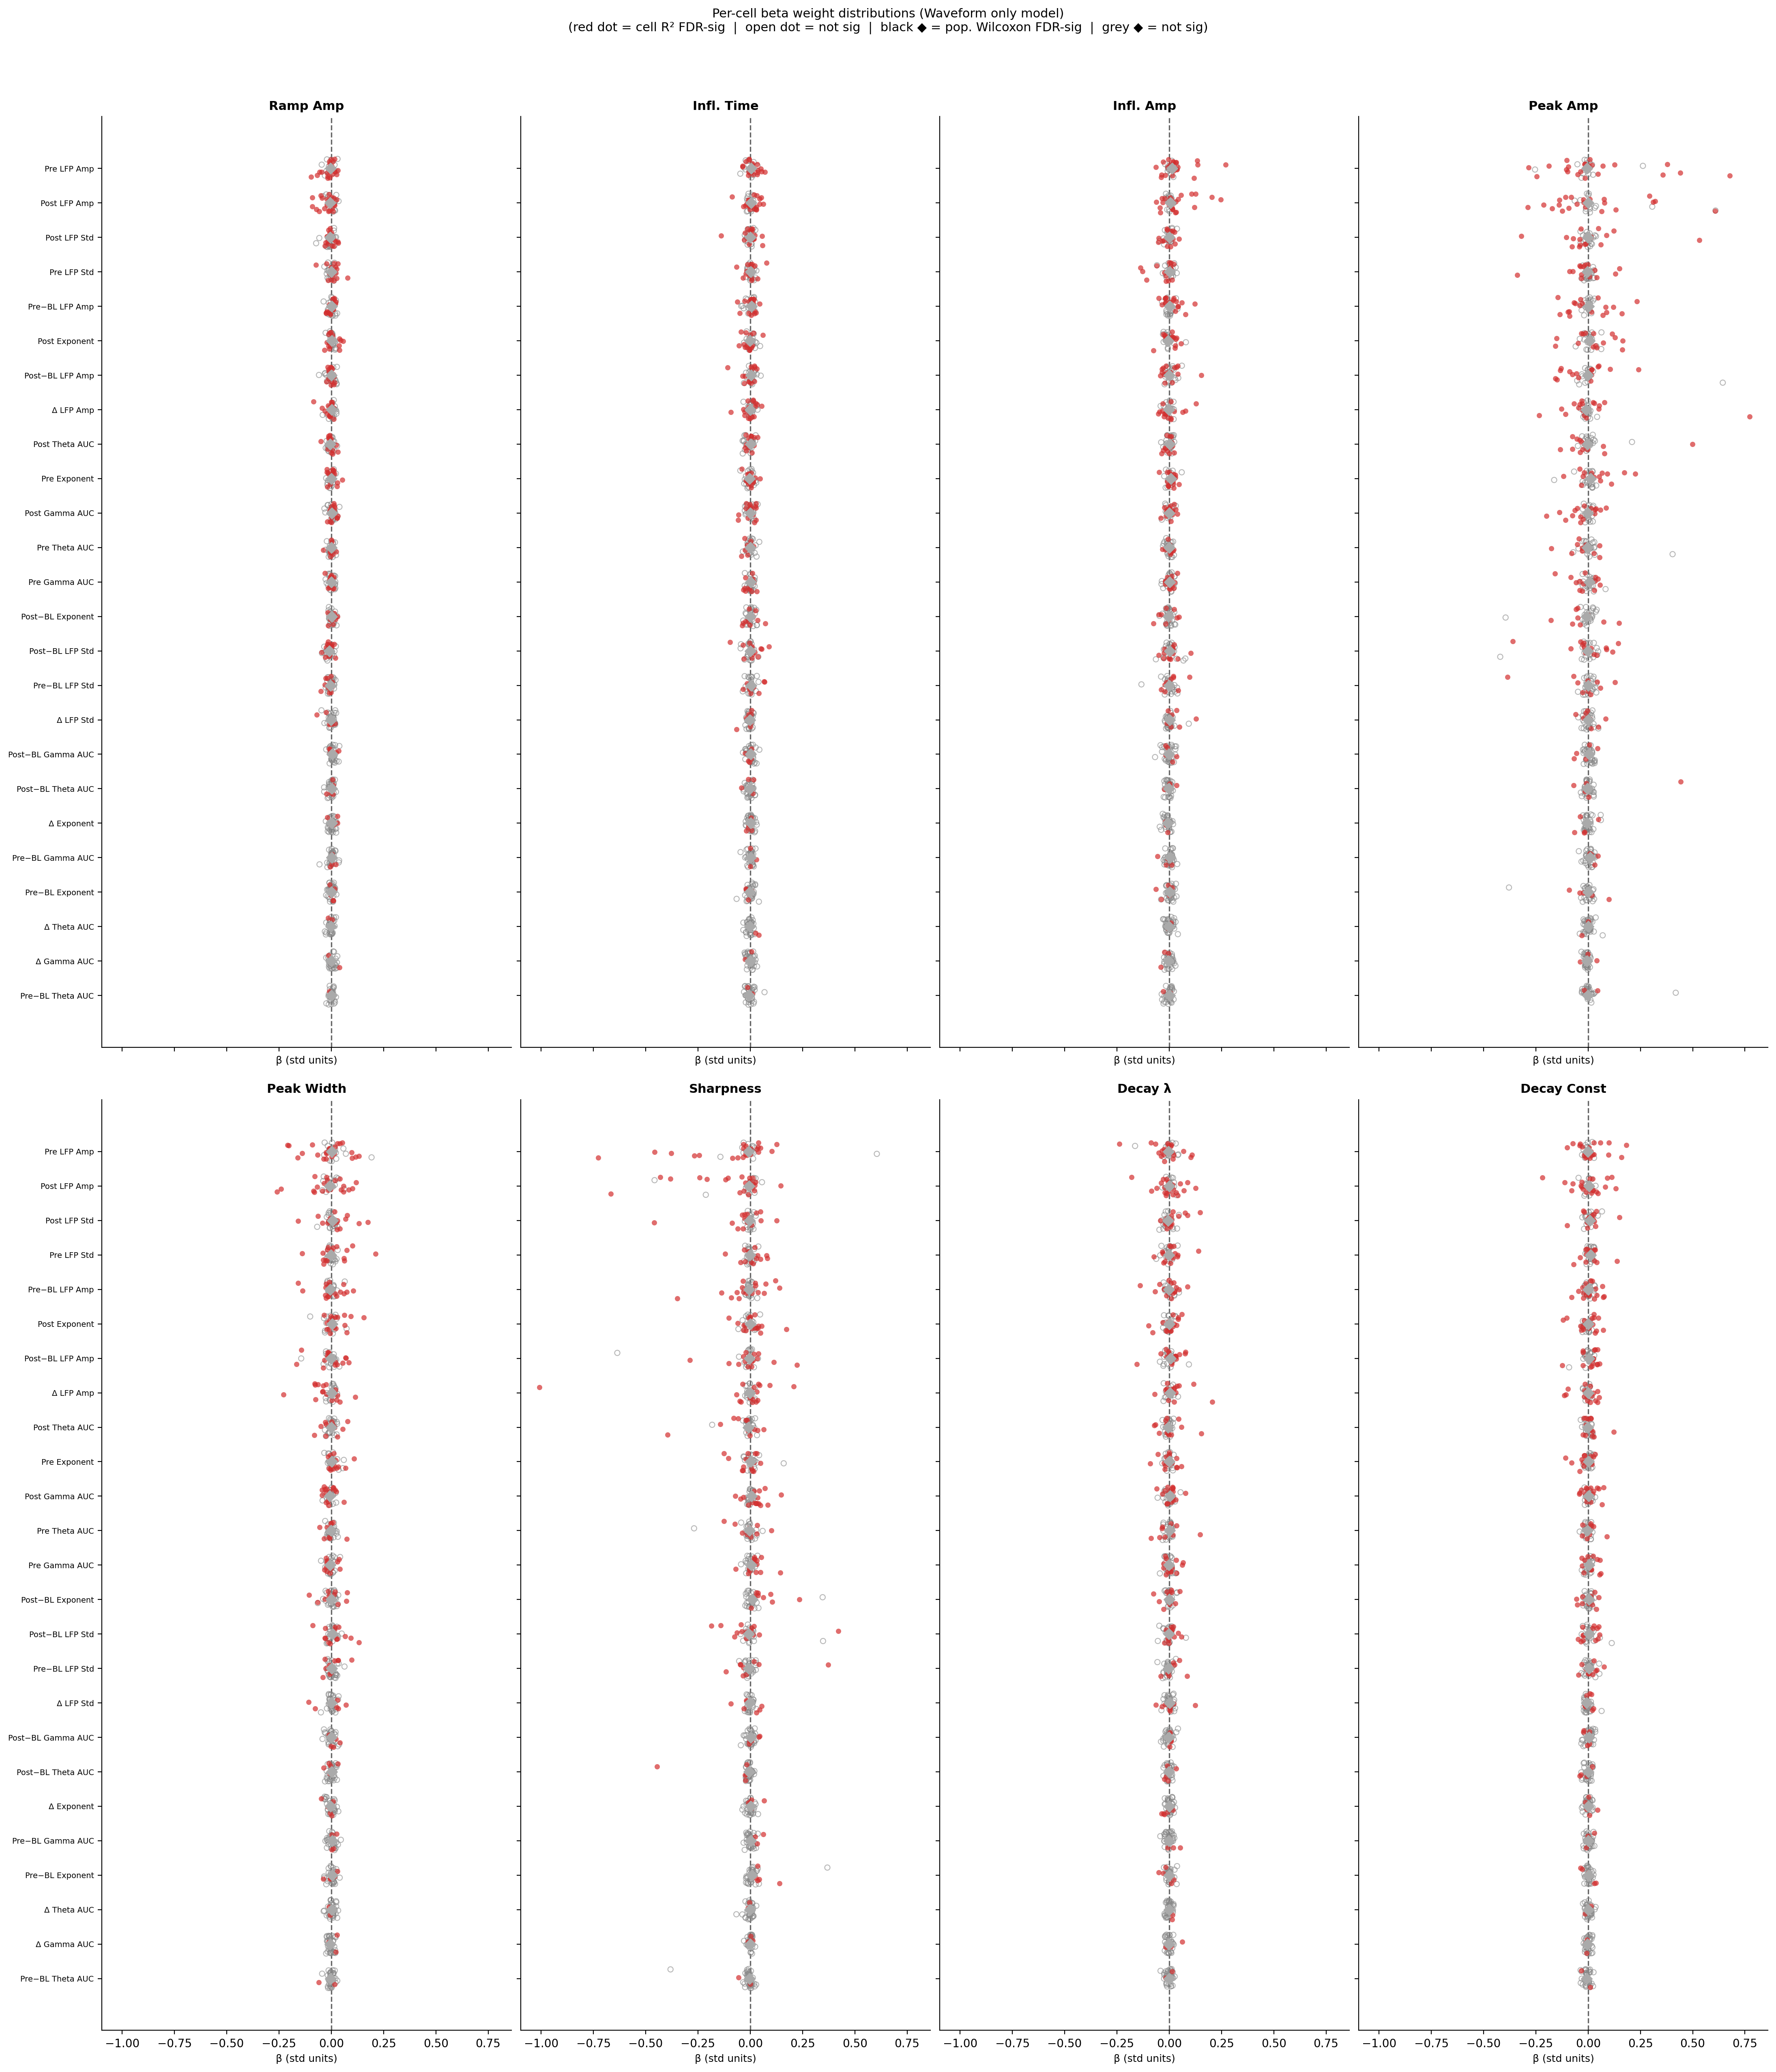

In [9]:
# ── 4c. Beta distributions across cells ──────────────────────────────────────
# One panel per waveform feature; targets sorted by mean R² (same order as R² plot).
# Dot colour: red = that cell's R² model was FDR-significant; grey = not significant.
# Median ◆: black = population Wilcoxon FDR-significant for that target × feature.
plot_beta_distributions(beta_pop, df_tests, target_names, target_labels,
                        sig_pop=sig_pop, sig_pset='Waveform only',
                        sort_by='mean_r2', r2_pop=r2_pop)

## 5. Actual vs predicted scatter (pooled)

Each point is one spike from one cell, z-scored within cell before pooling.  
Only cells with FDR-significant Waveform-only models are included.  
Each colour = one cell.

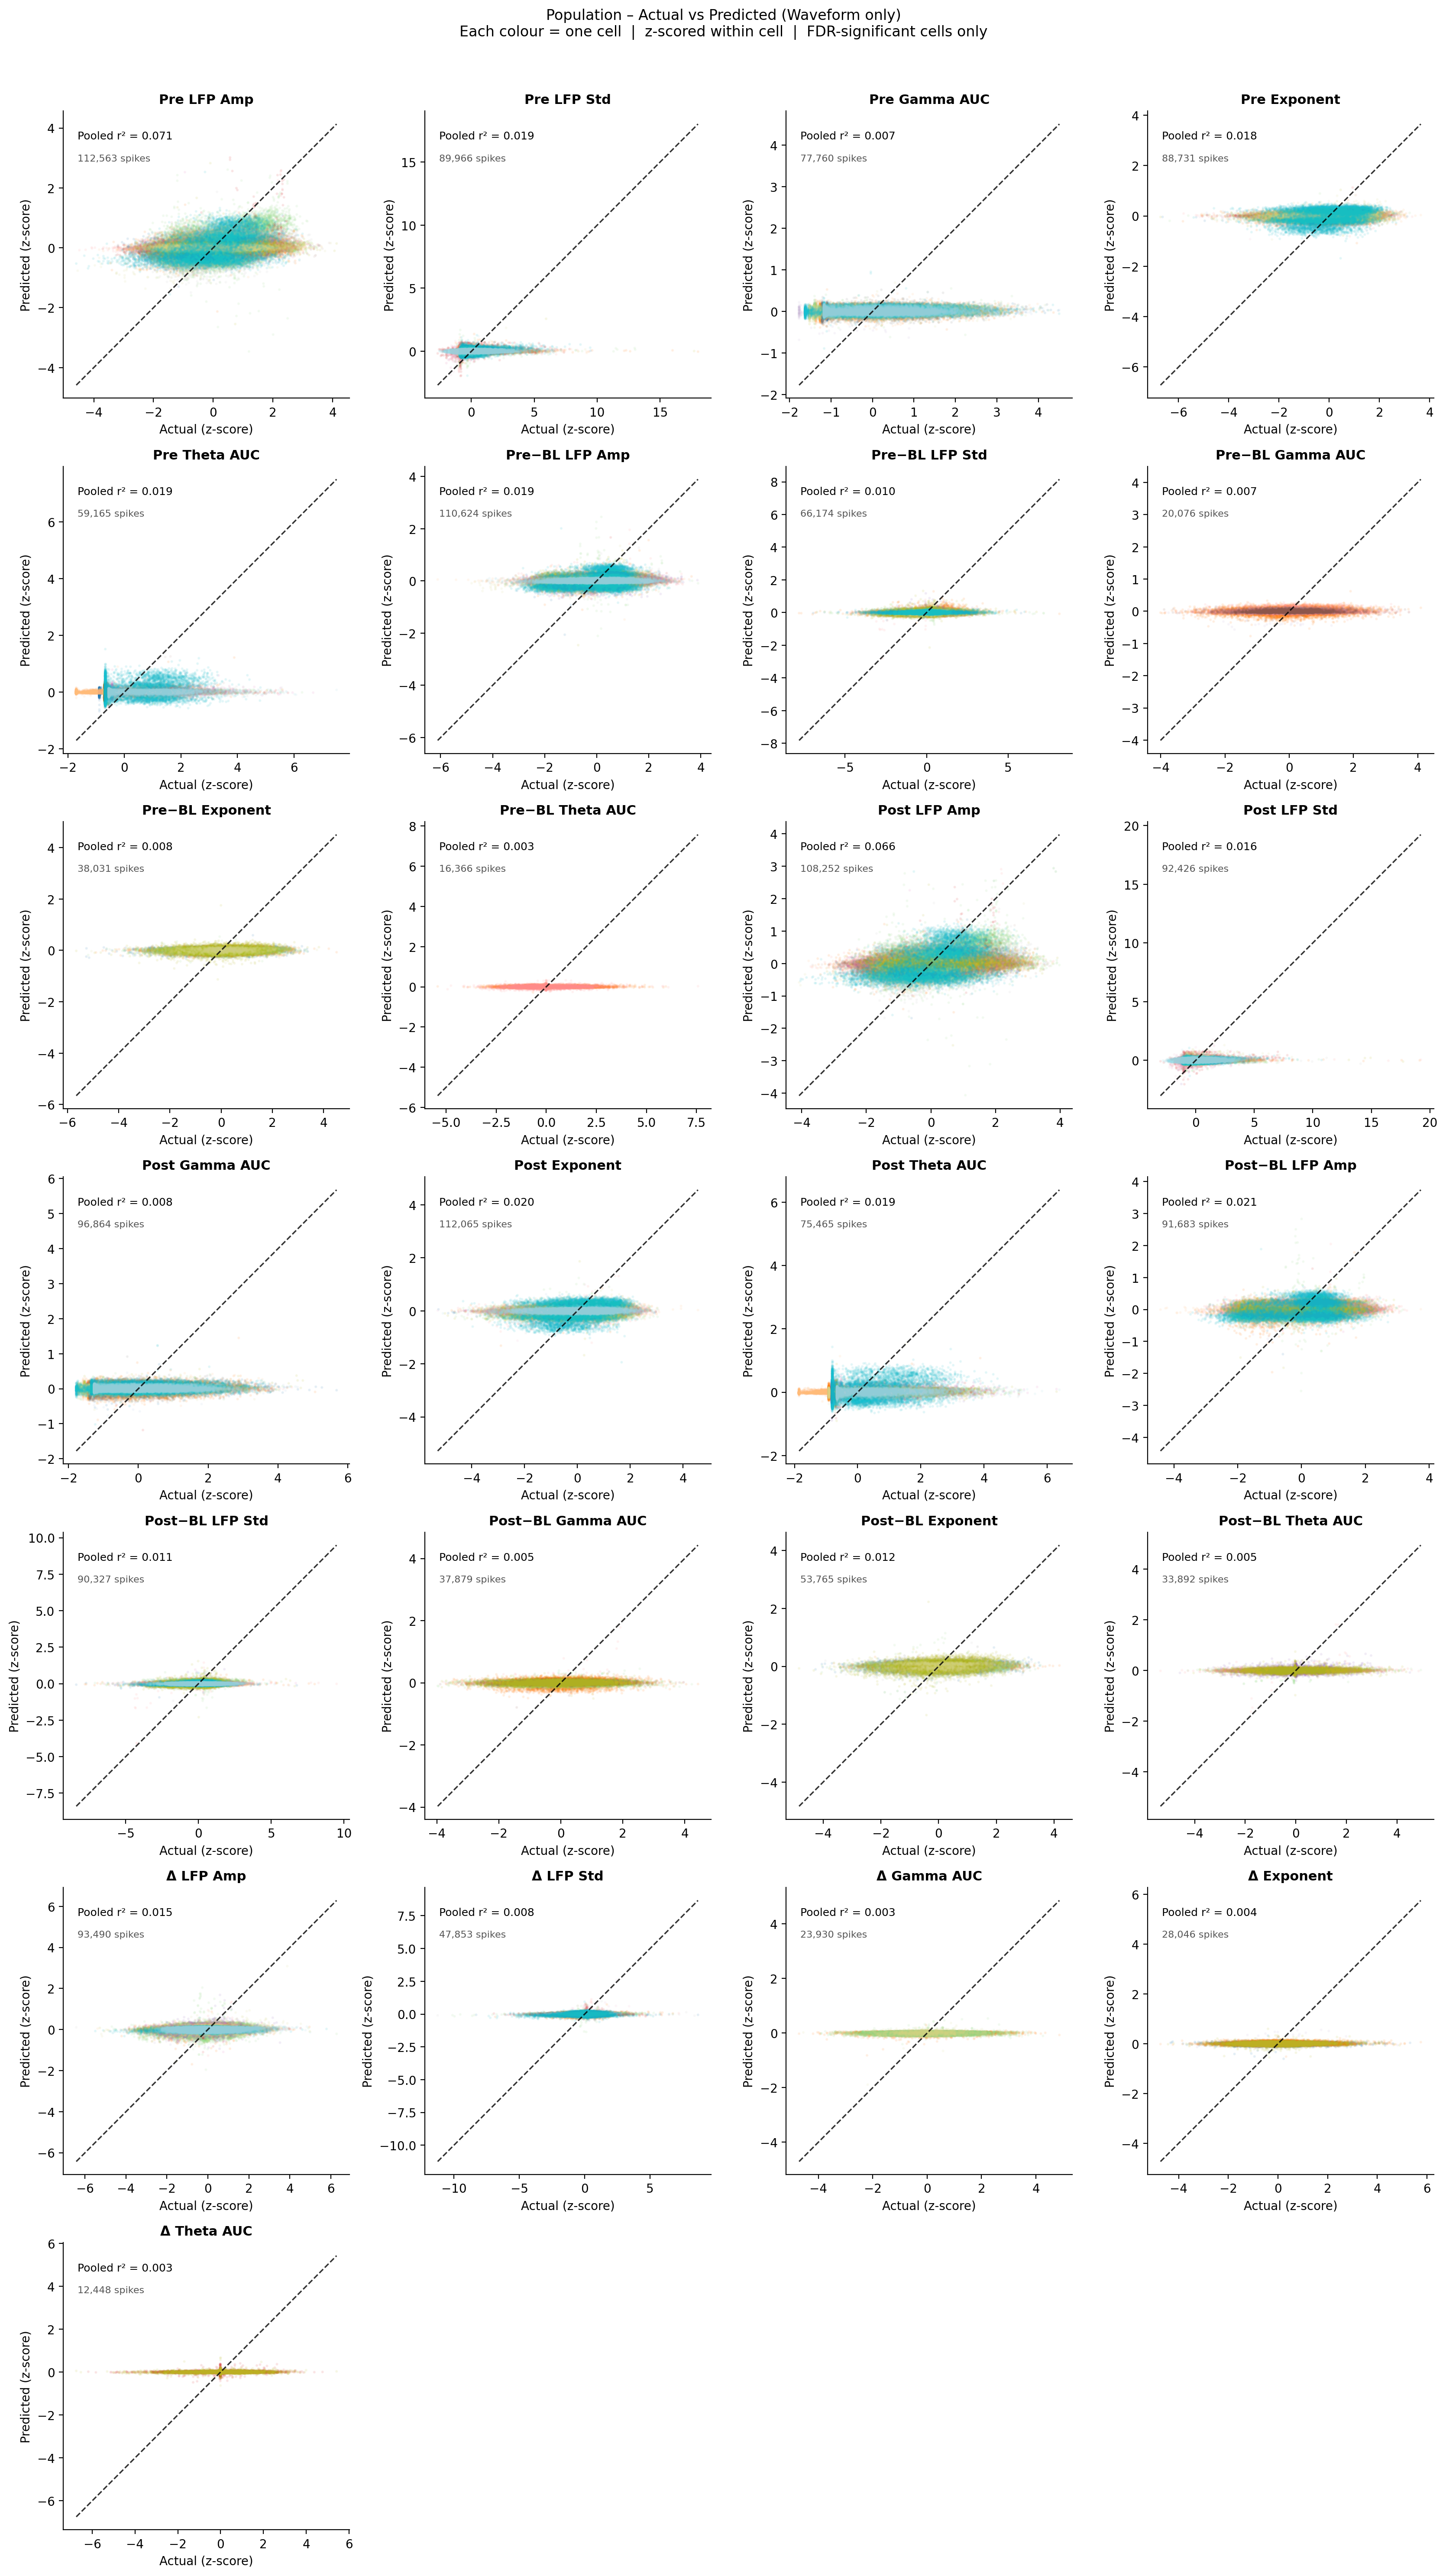

In [10]:
# ── 5. Population scatter (reads from pickles — fast) ────────────────────────
build_population_scatter(all_results, cell_ids, target_names, target_labels)

In [11]:
# ── 6. Save ───────────────────────────────────────────────────────────────────
save_population_results(
    RIDGE_PICKLE_DIR, r2_pop, sig_pop, beta_pop, df_tests,
    mean_r2, frac_sig, mean_beta_mat, sig_beta_mat,
    target_names, target_labels, predictor_sets, cell_ids,
    df_frac=df_frac, df_r2=df_r2,
)

Saved: population_ridge_results.pkl


## 7. HPF vs no-HPF comparison

The 0.1 Hz HPF removes slow electrode drift before computing LFP amplitude and std targets.
This section loads both versions and compares R² and significant targets side by side.

**No HPF**: raw LFP windows (bandpassed 0.1–250 Hz at acquisition), mean/std computed directly.  
**HPF 0.1 Hz**: same windows high-passed at 0.1 Hz before computing mean/std.

The comparison shows how much of the original signal survives detrending, and whether the
waveform → LFP relationship is driven by slow drift or genuine network-state coupling.

In [ ]:
# ── 7. HPF vs no-HPF R² comparison ────────────────────────────────────────────
import pickle, glob, os
import pandas as pd
from IPython.display import display

def _load_results(pickle_dir, suffix=''):
    """Load per-cell ridge results with optional filename suffix (e.g. '_hpf')."""
    pkls = sorted(glob.glob(os.path.join(pickle_dir, f'c*_ridge_results{suffix}.pkl')))
    pkls = [p for p in pkls if 'population' not in os.path.basename(p)]
    results = {}
    for p in pkls:
        cid = os.path.basename(p).replace(f'_ridge_results{suffix}.pkl', '')
        with open(p, 'rb') as f:
            results[cid] = pickle.load(f)
    return results

# Load both versions
res_raw = _load_results(RIDGE_PICKLE_DIR, suffix='')
res_hpf = _load_results(RIDGE_PICKLE_DIR, suffix='_hpf')

missing = set(cell_ids) - set(res_raw.keys())
if missing:
    print(f'⚠  No-HPF pickles missing for: {sorted(missing)} — run batch with HPF_CUTOFF=0')
else:
    print(f'No-HPF:  {len(res_raw)} cells')
    print(f'HPF 0.1Hz: {len(res_hpf)} cells')

    # Aggregate R² for both
    r2_raw, _, _ = aggregate_population(res_raw, cell_ids, target_names, predictor_sets)
    r2_hpf, _, _ = aggregate_population(res_hpf, cell_ids, target_names, predictor_sets)

    df_r2_raw = run_r2_tests(r2_raw, target_names, target_labels, predictor_sets,
                              min_cells=MIN_CELLS, fdr_q=FDR_Q)
    df_r2_hpf = run_r2_tests(r2_hpf, target_names, target_labels, predictor_sets,
                              min_cells=MIN_CELLS, fdr_q=FDR_Q)

    # Side-by-side table for Waveform-only, LFP amp and std targets
    amp_std = ['pre_lfp_amp', 'pre_lfp_std', 'post_lfp_amp', 'post_lfp_std']
    rows = []
    for tn in amp_std:
        tl = dict(zip(target_names, target_labels))[tn]
        for label, df_r2_ in [('No HPF', df_r2_raw), ('HPF 0.1 Hz', df_r2_hpf)]:
            row_ = df_r2_[(df_r2_['target'] == tn) &
                          (df_r2_['predictor_set'] == 'Waveform only')]
            if len(row_):
                r = row_.iloc[0]
                rows.append(dict(
                    Target=tl, Version=label,
                    N=int(r['n_cells']),
                    median_r2=r['median_r2'],
                    mean_r2=r['mean_r2'],
                    sig='✓' if r['sig_r2'] else '✗',
                    p_fdr=r['p_wilcox_fdr'],
                ))

    df_cmp = pd.DataFrame(rows)
    styled = (
        df_cmp.style
        .format({'median_r2': '{:.4f}', 'mean_r2': '{:.4f}', 'p_fdr': '{:.4f}'})
        .set_caption('R² comparison: HPF vs no HPF  |  Waveform-only predictor set')
        .set_table_styles([{'selector': 'caption',
                            'props': [('font-size', '13px'), ('font-weight', 'bold')]}])
    )
    display(styled)